In [1]:
#################################################################################
# Main script to run UP-MAVT analysis
#
# Simone Pagliuca, 2025-2026
#
# Description:
# TBC....
#################################################################################

#################################################################################
# Import third party libraries
import numpy as np
# import matplotlib
# matplotlib.use('TkAgg')  # Set backend before importing pyplot
import matplotlib.pyplot as plt
import seaborn as sns
import os
import csv
#################################################################################

#################################################################################
# Import internal modules
from pile_bwt import bwt, constraints_func
from up_mavt import startup, mc_simulation
from aggregation_methods import weighted_sum
from weight_sampling import obtain_weight_space_description
#################################################################################

#################################################################################
# USER INPUTS
# Weight elicitation files (one per elicitation / run)
file_path_weight_elicitations = ["wbt_results_1.csv"]

# Value function files (one per elicitation / run)
file_path_value_functions = ["value_functions_1.csv"]

# Criteria definitions file
file_path_criteria = "criteria.csv"

# Montecarlo Parameters
n_runs = 10000
PLOTS = True  # Toggle plots
UPDATE_EVERY = 10  # Update plots every N runs
#################################################################################


#################################################################################
# Startup: Load all data
dict_data_list, crit_index, vf_list, alternatives = startup(file_path_criteria, file_path_weight_elicitations, file_path_value_functions)
n_alternatives = len(alternatives)
print(f"Loaded {len(dict_data_list)} elicitation(s) with {n_alternatives} alternatives.")
#################################################################################


Loading criteria definitions and attaching value functions...
Starting loop over weight elicitation files...
Processing file 1/1: wbt_results_1.csv
Loaded 1 elicitation(s) with 4 alternatives.


In [2]:

#################################################################################
# PILE-BWT Method
# 
# Work in progress while we try to fix issues with constraints and solver
# For now it runs the BWT optimization and then tries to sample more values from the space
print("Running BWT for each elicitation...")
bwt_results = []

for i, dict_data in enumerate(dict_data_list):
    print(f"Running BWT for elicitation {i+1}...")  # Debugging: Print elicitation index
    bwt_result = bwt(dict_data)
    bwt_results.append(bwt_result)
    
print(bwt_result["solver_result"])



Running BWT for each elicitation...
Running BWT for elicitation 1...
Running optimization...
     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 1.2279981273412224
           x: [ 2.374e-01  6.435e-02 ...  8.859e-03  1.228e+00]
         nit: 20
         jac: [ 0.000e+00  0.000e+00 ...  0.000e+00  1.000e+00]
        nfev: 258
        njev: 17
 multipliers: [-6.064e-08  0.000e+00 ...  5.175e-11  0.000e+00]


/home/simo/GitHub/Master-Thesis/UP-MAVT/pile_bwt.py:49: RuntimeWarning: divide by zero encountered in scalar divide
  cons.append(z - abs(w[i] / w[j] - 1.0 / v_f(value)))
/home/simo/GitHub/Master-Thesis/UP-MAVT/pile_bwt.py:57: RuntimeWarning: divide by zero encountered in scalar divide
  cons.append(z - abs(1.0 / v_f_other(value) - (w[j] / w[i])))
/home/simo/GitHub/Master-Thesis/UP-MAVT/pile_bwt.py:57: RuntimeWarning: invalid value encountered in scalar divide
  cons.append(z - abs(1.0 / v_f_other(value) - (w[j] / w[i])))
/home/simo/GitHub/Master-Thesis/UP-MAVT/pile_bwt.py:90: RuntimeWarning: divide by zero encountered in scalar divide
  cons.append(x[-1] - abs((x[ref_global_index] / x[other_global_index]) - (1.0 / v_f(comparison['value']))))
/home/simo/GitHub/Master-Thesis/UP-MAVT/pile_bwt.py:95: RuntimeWarning: invalid value encountered in scalar divide
  cons.append(x[-1] - abs(1.0 / v_f_other(comparison['value']) - (x[other_global_index] / x[ref_global_index])))
/home/simo/GitHub/M

In [3]:

print("\033[93mTesting with BWT results...\033[0m")
x_weights = bwt_result["solver_result"]["x"][:-1]
x_temp = np.concatenate([x_weights, [0]])
constraint_value = constraints_func(x_temp, dict_data)
error_b = min(max([abs(cv) for cv in constraint_value]), 10)
for c in constraint_value:
    c_py = float(c)
    print(c_py)  # Debugging: print as native Python float
print(f"\033[91mMaximum constraint violation (error_b): {error_b}\033[0m")  # Debugging
known_max_error = error_b
print("\n")
print(x_weights)


Testing with BWT results...
-0.3102519186786088
-1.2279981273404346
-1.2279955428074834
-1.2279981273414053
-1.2279981273397187
-0.22799812734153235
-0.26402247190219974
-1.227998127336834
-0.874085490962466
-0.2640224719002404
-1.2279981273396139
-0.8740854909630846
-1.227998127341245
-1.2279981273426763
-0.7720018726590911
-1.2279981273403857
-1.2279981273410847
-1.2279981273411211
-0.2640224719048767
-1.2279981273395126
-1.2279981273407259
-1.2279981273407101
Maximum constraint violation (error_b): 1.2279981273426763


[0.23744502 0.06435264 0.0232152  0.04113738 0.42075302 0.07289551
 0.04113738 0.00444055 0.00499968 0.07289551 0.00786867 0.00885945]


Testing with GA river results...


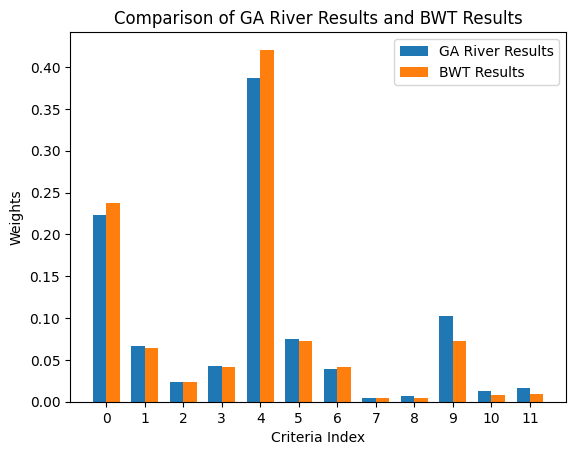

In [4]:


print("\033[93mTesting with GA river results...\033[0m")
GA_river_results = [0.223107136295446, 0.066938158864609, 0.0240362056402704, 0.042354197922861, 0.387345646508799, 0.0745301854344023, 0.0387849189677758,0.00493893186225466, 0.00642169382682608,0.102166457316974,0.0124955605811967,0.0168809067785853]

# plot the GA river results and x_weights for comparison
indices = np.arange(len(GA_river_results))
width = 0.35
plt.bar(indices - width/2, GA_river_results, width, label='GA River Results')
plt.bar(indices + width/2, x_weights, width, label='BWT Results')
plt.xlabel('Criteria Index')
plt.ylabel('Weights')
plt.title('Comparison of GA River Results and BWT Results')
plt.xticks(indices)
plt.legend()



In [5]:

x_temp = np.concatenate([GA_river_results, [0]])
constraint_value = constraints_func(x_temp, dict_data)
error_b = max([abs(cv) for cv in constraint_value])
for c in constraint_value:
    c_py = float(c)
    print(-c_py)  # Debugging: print as native Python float
print(f"\033[91mMaximum constraint violation (error_b): {error_b}\033[0m")  # Debugging


0.6669663450602399
0.2821279545741202
1.2151112423310106
1.2403117261211534
0.1453897253411629
0.8028353310656788
1.1471038577822794
0.9603288456769619
0.6997808421081297
0.8237796013158523
0.9478098743735837
0.6490476622563326
1.263858104494413
0.9870170369731248
1.2086808461308451
1.2475801875256423
0.36582001365380323
1.2379000014918942
0.424421493532007
0.6104603592898799
0.8666809566588531
0.4699872503419429
Maximum constraint violation (error_b): 1.263858104494413


In [6]:

from weight_sampling import obtain_weight_space_description
num_criteria = len(GA_river_results)
used_cells = set()
grid_size = np.int64(1000)
n_dimensions = num_criteria
# print("Number of dimensions for sampling:", n_dimensions)
nx = np.array([grid_size] * n_dimensions, dtype=np.int64)

initial_point = bwt_result["solver_result"]["x"][:num_criteria]
# print("Initial point for sampling:", initial_point)
initial_cell = tuple(np.clip((np.array(initial_point) * grid_size).astype(np.int64), 0, grid_size - 1))
used_cells.add(initial_cell)
valid_points = [np.array(initial_cell, dtype=np.float64) / grid_size]

print("Starting space sampling...")
print(f"Grid size: {grid_size}, Number of dimensions: {n_dimensions}")
print(f"Initial point: {initial_point}, Initial cell: {initial_cell}")


Starting space sampling...
Grid size: 1000, Number of dimensions: 12
Initial point: [0.23744502 0.06435264 0.0232152  0.04113738 0.42075302 0.07289551
 0.04113738 0.00444055 0.00499968 0.07289551 0.00786867 0.00885945], Initial cell: (np.int64(237), np.int64(64), np.int64(23), np.int64(41), np.int64(420), np.int64(72), np.int64(41), np.int64(4), np.int64(4), np.int64(72), np.int64(7), np.int64(8))


In [7]:
print(known_max_error)

1.2279981273426763


Generating weight samples for elicitation 1...
Running optimization...
SLSQP failed (message: Singular matrix E in LSQ subproblem)
Trying 'COBYLA' as fallback with explicit bound constraints...
COBYLA failed (message: Did not converge to a solution satisfying the constraints. See `maxcv` for the magnitude of the violation.)
maxcv=1.6862943930107122e-07
COBYLA produced near-feasible solution: accepting result.
Running optimization...
Running optimization...
Running optimization...
Running optimization...
Running optimization...
Running optimization...
Running optimization...
Running optimization...
Running optimization...
Running optimization...
Running optimization...
Running optimization...
Running optimization...
Running optimization...
Running optimization...
Running optimization...
Running optimization...
Running optimization...
Running optimization...
Running optimization...
Running optimization...
Running optimization...
Running optimization...


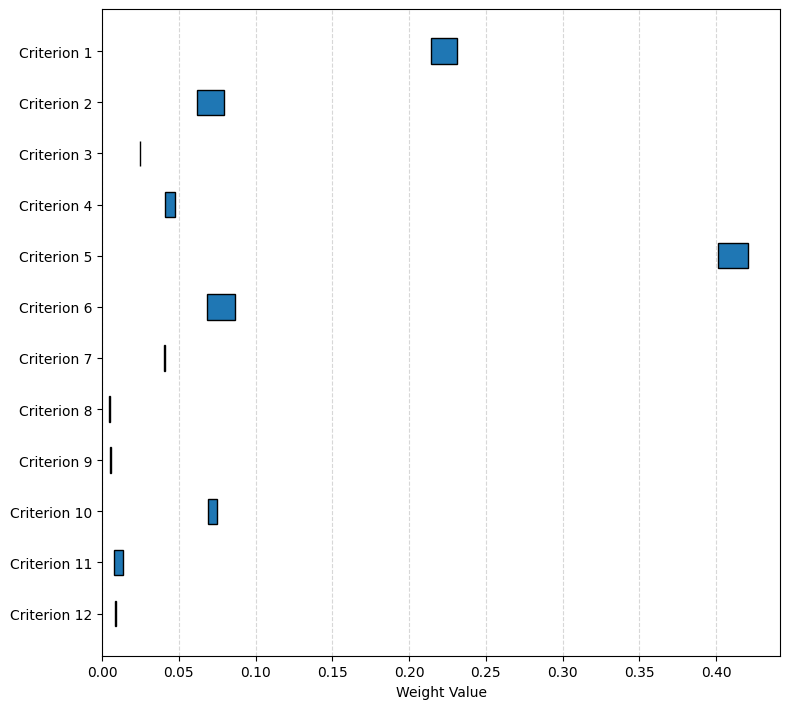

Total weight combinations to sample: 356610240 (values rounded to 3 decimals)


In [8]:
list_of_weight_space_points = obtain_weight_space_description(bwt_results, dict_data_list, file_path_weight_elicitations, crit_index)

In [9]:
# We then seelct one of the elicitated spaces
weight_space_points = list_of_weight_space_points[0]
print(weight_space_points)

[[0.215, 0.216, 0.217, 0.218, 0.219, 0.22, 0.221, 0.222, 0.223, 0.224, 0.225, 0.226, 0.227, 0.228, 0.229, 0.23, 0.231, 0.232], [0.062, 0.063, 0.064, 0.065, 0.066, 0.067, 0.068, 0.069, 0.07, 0.071, 0.072, 0.073, 0.074, 0.075, 0.076, 0.077, 0.078, 0.079, 0.08], [np.float64(0.025)], [0.042, 0.043, 0.044, 0.045, 0.046, 0.047, 0.048], [0.402, 0.403, 0.404, 0.405, 0.406, 0.407, 0.408, 0.409, 0.41, 0.411, 0.412, 0.413, 0.414, 0.415, 0.416, 0.417, 0.418, 0.419, 0.42, 0.421], [0.069, 0.07, 0.071, 0.072, 0.073, 0.074, 0.075, 0.076, 0.077, 0.078, 0.079, 0.08, 0.081, 0.082, 0.083, 0.084, 0.085, 0.086, 0.087], [0.041, 0.042], [0.005, 0.006], [0.005, 0.006], [0.069, 0.07, 0.071, 0.072, 0.073, 0.074, 0.075], [0.008, 0.009, 0.01, 0.011, 0.012, 0.013, 0.014], [np.float64(0.009)]]


In [28]:
from weight_sampling import weight_sampler
weight_sampler(dict_data, weight_space_points)

[np.float64(0.232),
 np.float64(0.067),
 np.float64(0.025),
 np.float64(0.042),
 np.float64(0.413),
 np.float64(0.078),
 np.float64(0.041),
 np.float64(0.006),
 np.float64(0.005),
 np.float64(0.074),
 np.float64(0.008),
 np.float64(0.009)]